
# 🛢️ Oil Price Forecasting Lecture Notebook  
## SARIMA, N-BEATSx, and LSTM-Transformer  
### + Scenario & Sensitivity Analysis

This notebook covers:

- Oil price time series modeling
- SARIMA (statistical baseline)
- Deep learning models:
  - LSTM-Transformer hybrid
  - N-BEATSx (conceptual implementation)
- Scenario analysis (shock modeling)
- Sensitivity analysis (Monte Carlo)

---


In [33]:
#pip install pmdarima

In [35]:
pip install numpy==1.26.4 -q

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralforecast 1.7.6 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.2.3 requires torch>=1.11.0, which is not installed.
torchmetrics 1.6.0 requires torch>=2.0.0, which is not installed.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\anna_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, date
import os, sys, gc, pickle
np.random.seed(42)

import pmdarima as pm
from pmdarima.arima.utils import ndiffs


## pmdarima requires numpy less than 2

In [3]:
yf.__version__

'1.2.0'

## 📈 Prepare Oil Price Data from Yahoo Finance

In [2]:
def fetchOil(ticker: str, start: str | None, end: str | None, interval: str, out: str) -> pd.DataFrame:   

    if start is None:
        start = "2000-01-01"
    if end is None:
        end = date.today().isoformat()

    df = yf.download(ticker, start=start, end=end, interval=interval, progress=False)
    if df.empty:
        raise SystemExit(f"No data fetched for {ticker} (start={start}, end={end}).")

    # Ensure consistent column names
    df.columns = [c[0] for c in df.columns]

    # Fill small gaps then drop remaining missing rows
    df = df.ffill().bfill()

    # Primary price series
    if "Close" not in df.columns:
        raise SystemExit("Downloaded data contains no Close column.")

    df = df.loc[:, ["Open", "High", "Low", "Close", "Volume"]].copy()

    # Compute returns
    df["Return"] = df["Close"].pct_change()
    df["LogReturn"] = np.log(df["Close"]).diff()

    # Rolling features
    for w in (3, 5, 10, 20):
        df[f"MA_{w}"] = df["Close"].rolling(w).mean()
        df[f"STD_{w}"] = df["Close"].rolling(w).std()

    # Volatility (annualized approx from daily series)
    df["Volatility_20"] = df["Return"].rolling(20).std() * np.sqrt(252)

    # Drop initial rows with NaNs
    df = df.dropna()

    os.makedirs(os.path.dirname(out) or ".", exist_ok=True)
    df.to_csv(out, index=True)
    return df

In [3]:
oil_df = fetchOil("CL=F", start=None, end=None, interval="1d", out="data/oil_prices.csv")

C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
print(oil_df.shape)
oil_df.head()

(6410, 16)


,Open,High,Low,Close,Volume,Return,LogReturn,MA_3,STD_3,MA_5,STD_5,MA_10,STD_10,MA_20,STD_20,Volatility_20
Date,,,,,,,,,,,,,,,,
2000-09-21,34.650002,35.500000,33.349998,33.950001,110851,-0.094667,-0.099452,35.983334,1.830528,36.136000,1.360783,35.158,1.422039,34.2405,1.573683,0.525404
2000-09-22,34.000000,34.400002,32.500000,32.650002,85083,-0.038292,-0.039044,34.700001,2.510477,35.496001,2.087421,35.053,1.572465,34.2915,1.499404,0.543214
2000-09-25,31.400000,32.099998,31.049999,31.570000,104683,-0.033078,-0.033638,32.723334,1.191694,34.434000,2.514365,34.700,1.918819,34.2675,1.540451,0.555414
2000-09-26,32.000000,32.049999,31.400000,31.500000,67727,-0.002217,-0.002220,31.906667,0.644697,33.434000,2.481336,34.430,2.170453,34.1990,1.633514,0.547026
2000-09-27,31.950001,32.250000,31.400000,31.500000,86160,0.000000,0.000000,31.523333,0.040414,32.234000,1.076583,34.200,2.358361,34.1380,1.712519,0.546933


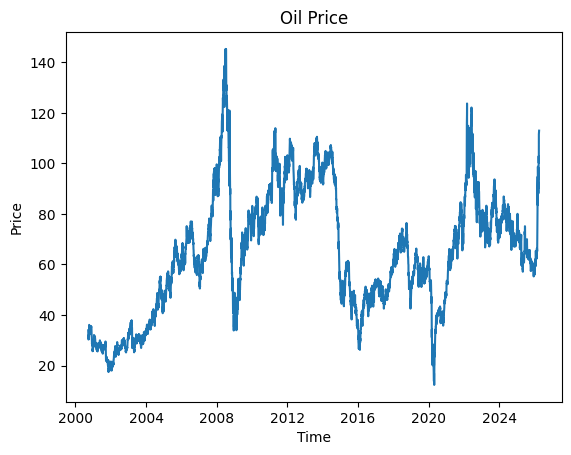

In [30]:
plt.plot(oil_df["Close"])
plt.title("Oil Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


In [ ]:
oil_df = pd.read_csv("data/oil_prices.csv", index_col=0, parse_dates=True)

## 🔹 SARIMA Model

In [7]:
# Determine optimal ARIMA/SARIMA order using pmdarima's auto_arima
series = oil_df['Close'].dropna()
print('Series length:', len(series))

# Suggest differencing order using unit-root tests
n_diffs = ndiffs(series, test='adf')
print('Suggested order of differencing (d):', n_diffs)

# Run auto_arima (seasonal with period m=30 by default here)
model = pm.auto_arima(
    series,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,            # let ndiffs decide
    seasonal=True,
    m=12,              # annual seasonal period f(adjust if needed)
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
)

print(model.summary())
print('Selected order (p,d,q):', model.order)
print('Selected seasonal_order (P,D,Q,m):', model.seasonal_order)

Series length: 6410
Suggested order of differencing (d): 1


C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

Performing stepwise search to minimize aic


C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=23926.285, Time=2.96 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=23933.728, Time=0.10 sec


...

 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=23920.572, Time=1.09 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=23932.125, Time=0.09 sec


C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=23930.421, Time=0.39 sec


C:\Users\anna_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


MemoryError: Unable to allocate 11.0 MiB for an array with shape (6410, 15, 15) and data type float64

In [ ]:
# Plot model diagnostics
model.plot_diagnostics(figsize=(12,8))
plt.show()

# (Optional) fit SARIMAX with chosen orders and forecast 30 steps
from statsmodels.tsa.statespace.sarimax import SARIMAX
order = model.order
seasonal_order = model.seasonal_order
sarimax_model = SARIMAX(series, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
res = sarimax_model.fit(disp=False)
print(res.summary())

fc = res.get_forecast(30)
pred = fc.predicted_mean
plt.figure(figsize=(10,4))
plt.plot(series.index, series, label='Observed')
plt.plot(pred.index, pred, label='SARIMAX Forecast')
plt.legend()
plt.title('SARIMAX Forecast using auto_arima-selected orders')
plt.show()

In [ ]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df["price"], order=(1,1,1), seasonal_order=(1,1,1,30))
results = model.fit(disp=False)

forecast = results.forecast(30)

plt.plot(df["price"], label="Observed")
plt.plot(range(len(df), len(df)+30), forecast, label="Forecast")
plt.legend()
plt.title("SARIMA Forecast")
plt.show()


## 🤖 LSTM-Transformer Model

In [ ]:

import torch
import torch.nn as nn

class LSTMTransformer(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden_size, num_heads=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out[:, -1, :])

model = LSTMTransformer()
print(model)


## 🧠 N-BEATSx (Simplified Concept)

In [ ]:

class SimpleNBEATS(nn.Module):
    def __init__(self, input_size=20, hidden_size=64):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size)
        )

    def forward(self, x):
        return self.fc(x)

model_nbeats = SimpleNBEATS()
print(model_nbeats)


## 🔮 Scenario Analysis (Oil Market Shocks)

In [ ]:

baseline = df["price"].values[-30:]

# Oil shock scenarios
geopolitical_shock = baseline * 1.3
demand_crash = baseline * 0.7
supply_glut = baseline * 0.85

plt.plot(baseline, label="Baseline")
plt.plot(geopolitical_shock, label="Supply Shock ↑")
plt.plot(demand_crash, label="Demand Crash ↓")
plt.plot(supply_glut, label="Oversupply ↓")
plt.legend()
plt.title("Oil Price Scenarios")
plt.show()


## 🎲 Sensitivity Analysis (Monte Carlo)

In [ ]:

simulations = 500
results = []

last_price = df["price"].iloc[-1]

for _ in range(simulations):
    shock = np.random.normal(0, 0.05)
    simulated_price = last_price * (1 + shock)
    results.append(simulated_price)

results = np.array(results)

plt.hist(results, bins=30)
plt.title("Monte Carlo Distribution of Oil Prices")
plt.show()

print("Mean:", results.mean())
print("Std:", results.std())
